In [303]:
import kagglehub
import pandas as pd
import os
import warnings
warnings.filterwarnings(action='ignore')

# Download latest version
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: /home/solow/.cache/kagglehub/datasets/radheshyamkollipara/bank-customer-churn/versions/1


In [304]:
file=os.listdir(path=path)
file=path+'/'+file[0]
df=pd.read_csv(file)

In [305]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [306]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

In [307]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [308]:
df.isna().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [309]:
df.duplicated().sum()

np.int64(0)

In [310]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

In [311]:
df['Card Type'].value_counts().sort_values(ascending=True)

Card Type
PLATINUM    2495
SILVER      2496
GOLD        2502
DIAMOND     2507
Name: count, dtype: int64

In [312]:
df.groupby(['Gender','Geography'])['Balance'].sum().round()

Gender  Geography
Female  France       136389557.0
        Germany      142141138.0
        Spain         65189819.0
Male    France       174942922.0
        Germany      158261723.0
        Spain         87933733.0
Name: Balance, dtype: float64

In [313]:
df.groupby(['Satisfaction Score','Exited'])['Satisfaction Score'].sum()

Satisfaction Score  Exited
1                   0         1545
                    1          387
2                   0         3150
                    1          878
3                   0         4923
                    1         1203
4                   0         6376
                    1         1656
5                   0         8035
                    1         1985
Name: Satisfaction Score, dtype: int64

In [314]:
df.groupby(['NumOfProducts','HasCrCard'])['Point Earned'].count()

NumOfProducts  HasCrCard
1              0            1506
               1            3578
2              0            1344
               1            3246
3              0              76
               1             190
4              0              19
               1              41
Name: Point Earned, dtype: int64

In [315]:
df=df.drop(columns=['RowNumber','CustomerId','Surname'])

In [316]:
df.rename(columns={'Satisfaction Score':'SatisfactionScore','Point Earned':'PointEarned','Card Type':'CardType'},inplace=True)

In [317]:
df['Gender']=df['Gender'].map({'Female':0,'Male':1})

In [318]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned
0,619,France,0,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,0,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [319]:
numeric_col=['CreditScore','Age','Tenure','EstimatedSalary','PointEarned','Balance']

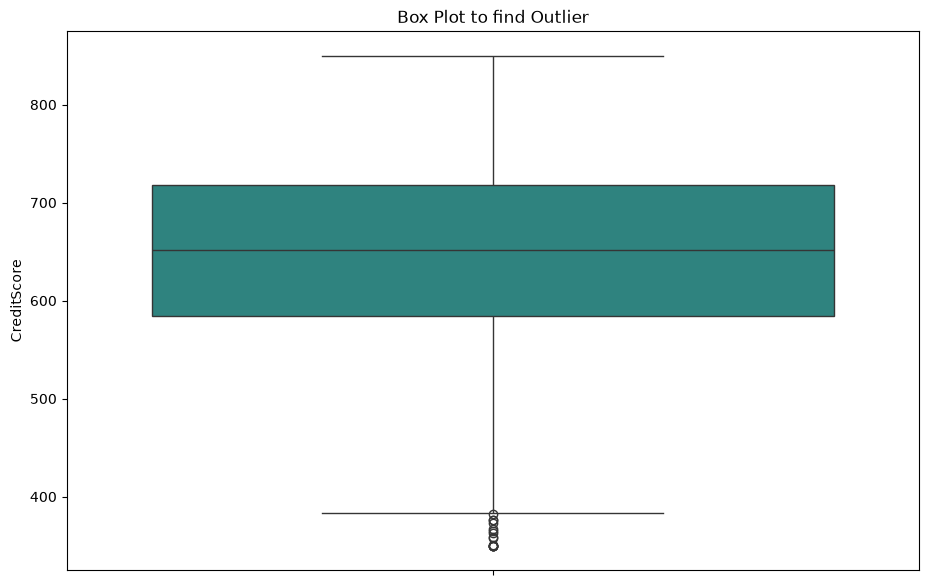

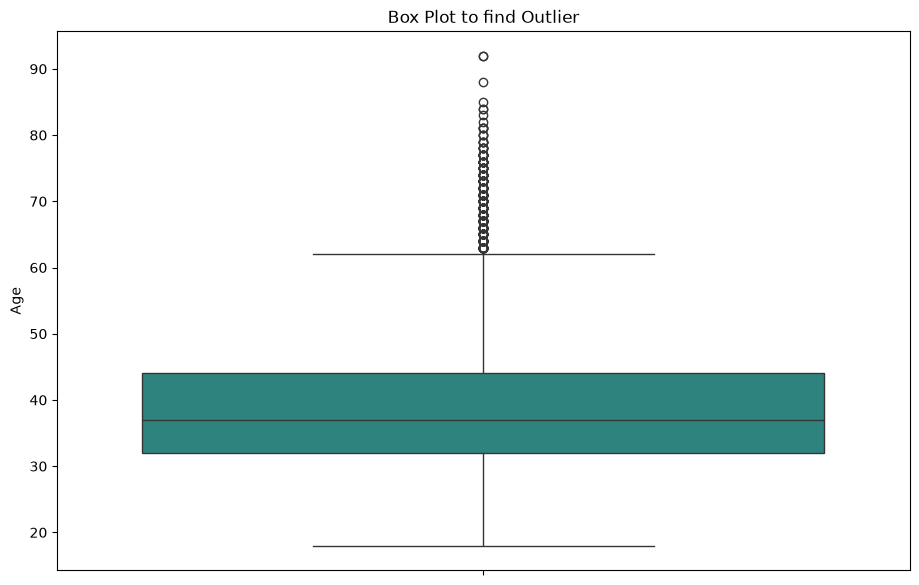

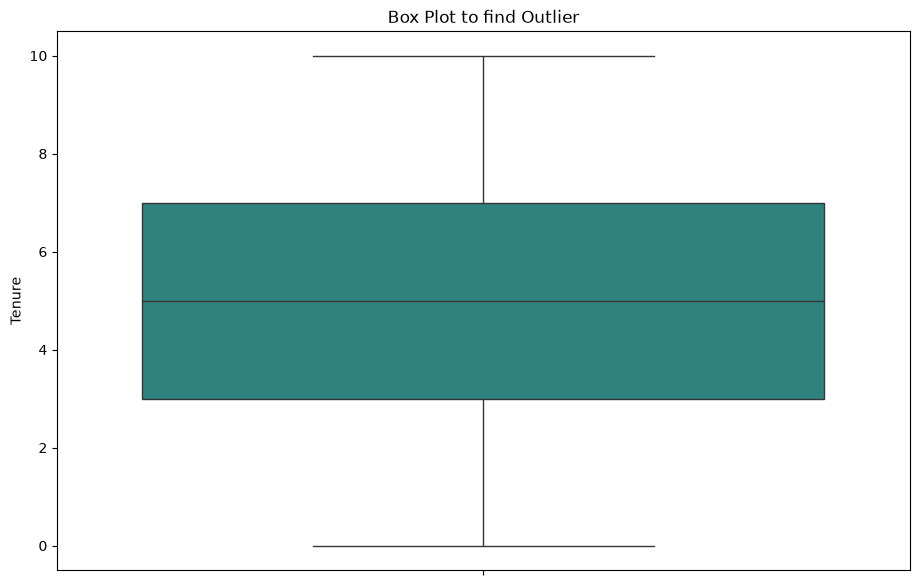

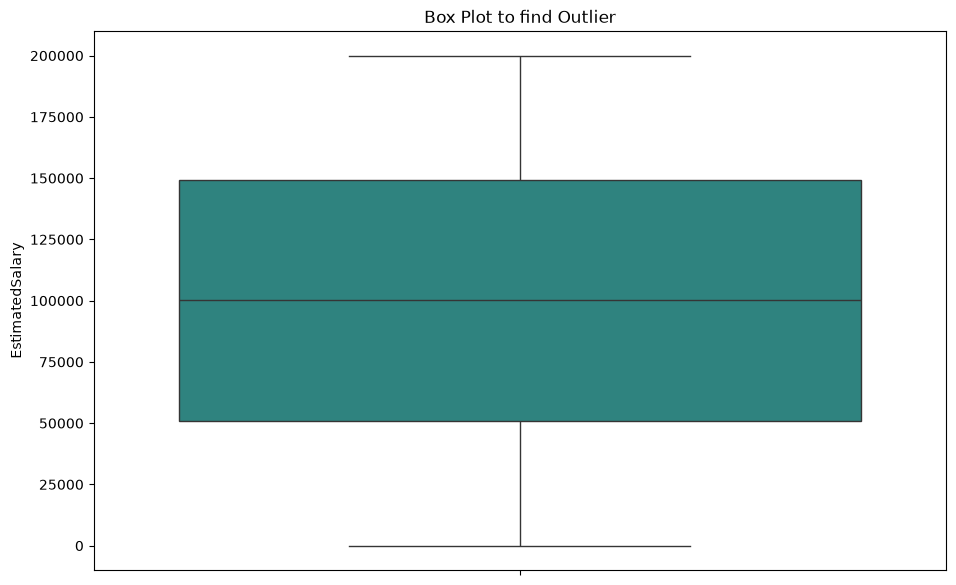

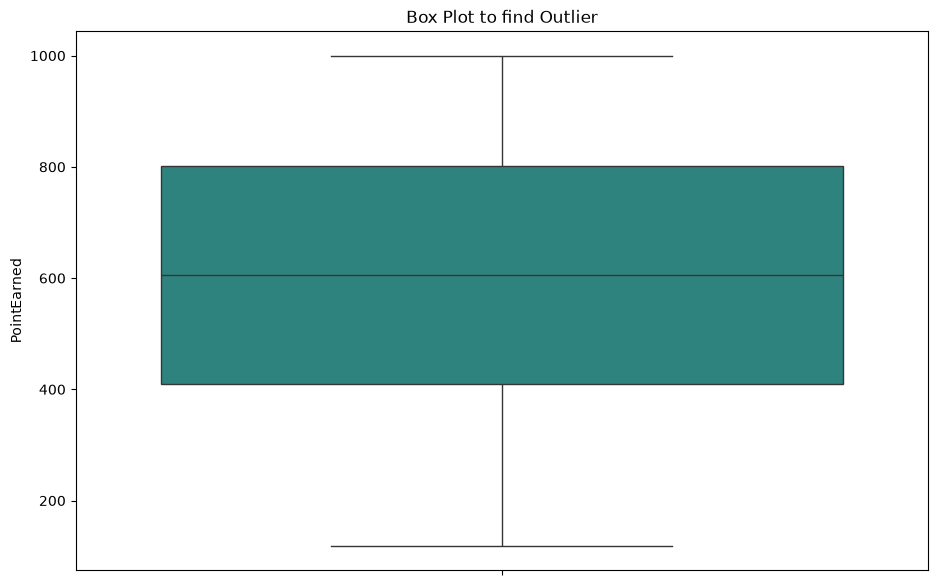

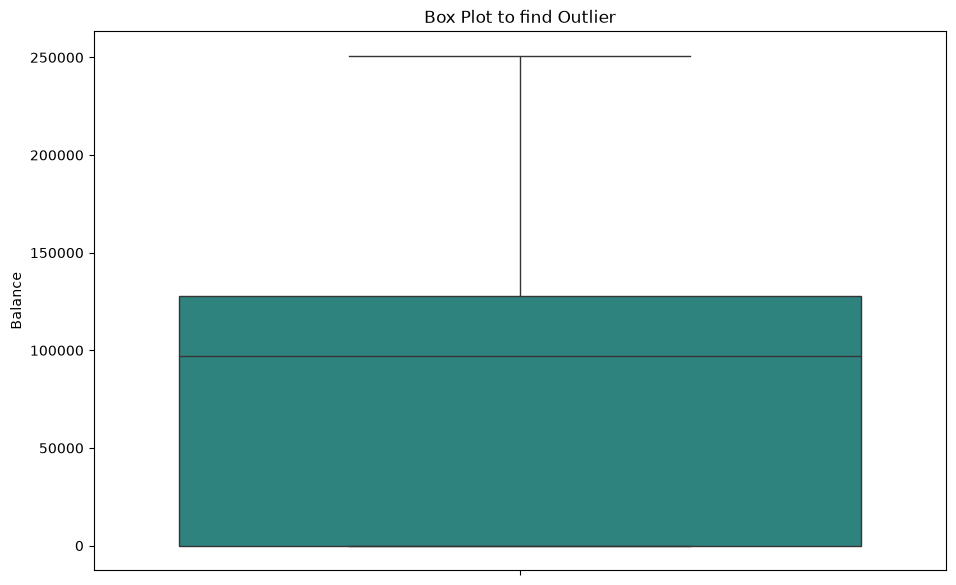

In [320]:
import seaborn as sns
import matplotlib.pyplot as plt
for each in numeric_col:
    fig,ax=plt.subplots(figsize=(11,7))
    sns.boxplot(df[each],ax=ax,palette='viridis')
    ax.set_title('Box Plot to find Outlier')
    plt.show()

In [321]:
outlier_col=['Age','CreditScore']
for each in outlier_col:
    q1=df[each].quantile(.25)
    q3=df[each].quantile(.75)
    iqr=q3-q1
    lower_bond=q1-1.5*iqr
    upper_bond=q3+1.5*iqr
    df=df[(df[each]>=lower_bond)&(df[each]<=upper_bond)]

In [322]:
df.info()

<class 'pandas.DataFrame'>
Index: 9627 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        9627 non-null   int64  
 1   Geography          9627 non-null   str    
 2   Gender             9627 non-null   int64  
 3   Age                9627 non-null   int64  
 4   Tenure             9627 non-null   int64  
 5   Balance            9627 non-null   float64
 6   NumOfProducts      9627 non-null   int64  
 7   HasCrCard          9627 non-null   int64  
 8   IsActiveMember     9627 non-null   int64  
 9   EstimatedSalary    9627 non-null   float64
 10  Exited             9627 non-null   int64  
 11  Complain           9627 non-null   int64  
 12  SatisfactionScore  9627 non-null   int64  
 13  CardType           9627 non-null   str    
 14  PointEarned        9627 non-null   int64  
dtypes: float64(2), int64(11), str(2)
memory usage: 1.2 MB


In [323]:
10000-9623

377

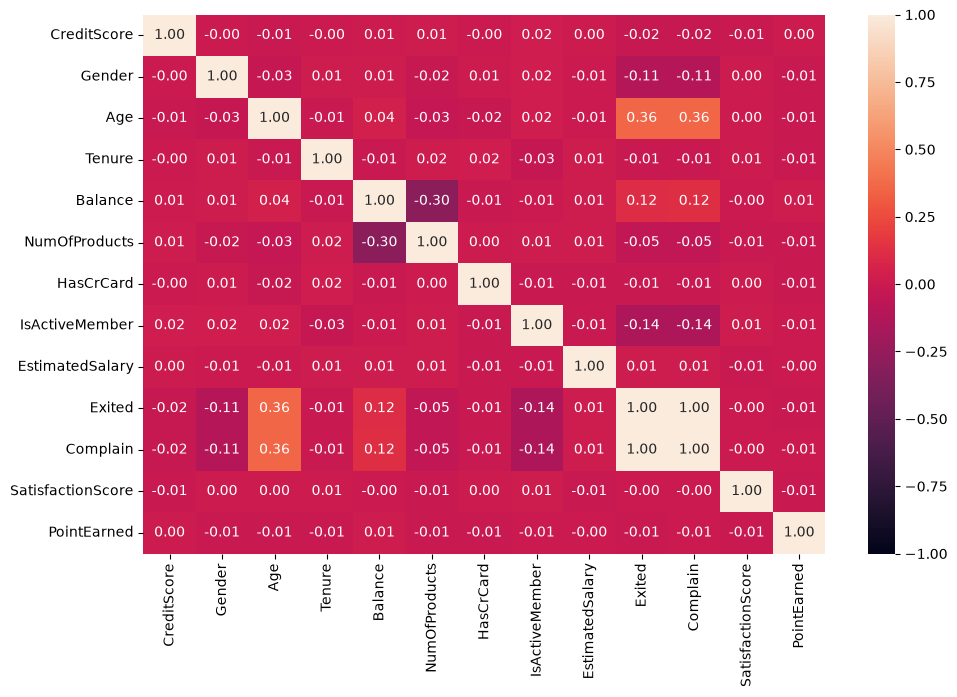

In [324]:
plt.figure(figsize=(11,7))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',vmax=1,vmin=-1)
plt.show()

In [325]:
df[numeric_col].skew()

CreditScore       -0.046587
Age                0.490903
Tenure             0.008881
EstimatedSalary   -0.000523
PointEarned        0.012474
Balance           -0.141304
dtype: float64

In [326]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned
0,619,France,0,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,0,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [327]:
df['CardType'].value_counts()

CardType
DIAMOND     2418
SILVER      2418
PLATINUM    2398
GOLD        2393
Name: count, dtype: int64

In [ ]:
skew_col=['Age']
other_num_col=['CreditScore','Tenure','Balance','EstimatedSalary','SatisfactionScore','PointEarned']
onehot_cat_col=['NumOfProducts','Geography']
binary_col=['Gender','HasCrCard','IsActiveMember']
ordinal_col=['CardType']
card_tier_order = ['SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']

In [329]:
feature=skew_col+other_num_col+onehot_cat_col+ordinal_col+binary_col
len(feature)

14

In [330]:
x=df[feature]
y=df['Exited']

In [331]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=24,test_size=.20,stratify=y)

In [332]:
x_train

,Age,CreditScore,Tenure,Balance,EstimatedSalary,SatisfactionScore,PointEarned,NumOfProducts,Geography,CardType,Gender,HasCrCard,IsActiveMember,Complain
5246,32,521,2,136555.01,129353.21,1,577,2,France,DIAMOND,0,1,1,0
8377,40,802,4,0.00,81908.09,3,841,2,Spain,DIAMOND,1,1,1,0
4274,42,502,0,132002.70,28204.98,3,403,1,Germany,SILVER,0,0,1,1
1429,26,601,8,78892.23,23703.52,1,876,1,France,SILVER,0,1,1,0
8502,37,530,8,0.00,287.99,4,605,2,France,DIAMOND,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5889,31,727,2,52192.08,160383.47,2,759,2,France,DIAMOND,0,0,1,0
6665,32,506,8,0.00,182692.80,4,671,2,Spain,DIAMOND,1,0,1,0
4622,48,564,5,132876.23,79259.77,1,741,1,Spain,DIAMOND,1,1,0,0
357,34,522,9,126436.29,174248.52,3,973,1,Spain,GOLD,1,1,0,1


In [333]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder

skew_pipeline=Pipeline(steps=[('FunctionTranformer',FunctionTransformer())
                              ,('StandardScalar',StandardScaler())])

other_num_pipeline=Pipeline(steps=[('StandardScalar',StandardScaler())])

onehot_cat_pipeline=Pipeline(steps=[('OneHotEncoding',OneHotEncoder())])

ordinal_pipeline=Pipeline(steps=[('OrdinalEncoding',OrdinalEncoder())])

In [334]:
preprocessor=ColumnTransformer(transformers=[('SkewFeature',skew_pipeline,skew_col)
                                             ,('OtherNumFeature',other_num_pipeline,other_num_col)
                                             ,('OneHotFeature',onehot_cat_pipeline,onehot_cat_col)
                                             ,('BinaryFeature','passthrough',binary_col)
                                             ,('OrdinalFeature',ordinal_pipeline,ordinal_col)])

In [335]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix,mean_absolute_error

lr_pipeline=Pipeline(steps=[('preprocessor',preprocessor)
                            ,('LogesticRegrssion',LogisticRegression())])

knn_pipeline=Pipeline(steps=[('preprocessor',preprocessor)
                             ,('Knn',KNeighborsClassifier())])

bernoulli_pipeline=Pipeline(steps=[('preprocessor',preprocessor)
                                   ,('BernoulliNB',BernoulliNB())])

decision_pipeline=Pipeline(steps=[('preprocessor',preprocessor)
                                  ,('DecisionTree',DecisionTreeClassifier())])


In [336]:
def EvaluationMetrix(y_test,prediction):
    fig, ax = plt.subplots(figsize=(6, 4))
    cm=confusion_matrix(y_test, prediction)
    sns.heatmap(cm,annot=True,fmt="d",ax=ax)
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    print('--'*20)
    print(classification_report(y_test,prediction))
    

In [337]:
x_train

,Age,CreditScore,Tenure,Balance,EstimatedSalary,SatisfactionScore,PointEarned,NumOfProducts,Geography,CardType,Gender,HasCrCard,IsActiveMember,Complain
5246,32,521,2,136555.01,129353.21,1,577,2,France,DIAMOND,0,1,1,0
8377,40,802,4,0.00,81908.09,3,841,2,Spain,DIAMOND,1,1,1,0
4274,42,502,0,132002.70,28204.98,3,403,1,Germany,SILVER,0,0,1,1
1429,26,601,8,78892.23,23703.52,1,876,1,France,SILVER,0,1,1,0
8502,37,530,8,0.00,287.99,4,605,2,France,DIAMOND,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5889,31,727,2,52192.08,160383.47,2,759,2,France,DIAMOND,0,0,1,0
6665,32,506,8,0.00,182692.80,4,671,2,Spain,DIAMOND,1,0,1,0
4622,48,564,5,132876.23,79259.77,1,741,1,Spain,DIAMOND,1,1,0,0
357,34,522,9,126436.29,174248.52,3,973,1,Spain,GOLD,1,1,0,1


In [338]:
x_train.columns

Index(['Age', 'CreditScore', 'Tenure', 'Balance', 'EstimatedSalary',
       'SatisfactionScore', 'PointEarned', 'NumOfProducts', 'Geography',
       'CardType', 'Gender', 'HasCrCard', 'IsActiveMember', 'Complain'],
      dtype='str')

LinearRegression

Traning Accuracy


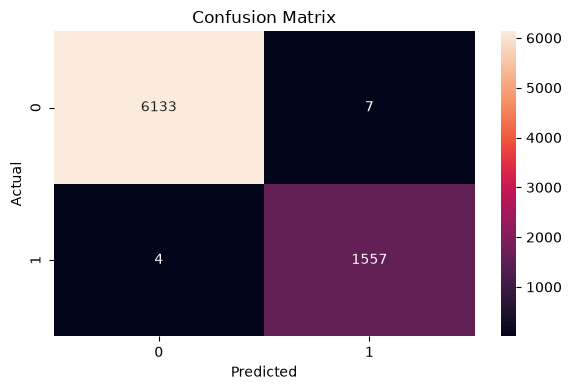

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6140
           1       1.00      1.00      1.00      1561

    accuracy                           1.00      7701
   macro avg       1.00      1.00      1.00      7701
weighted avg       1.00      1.00      1.00      7701

********************************************************************************
Testing Accuracy


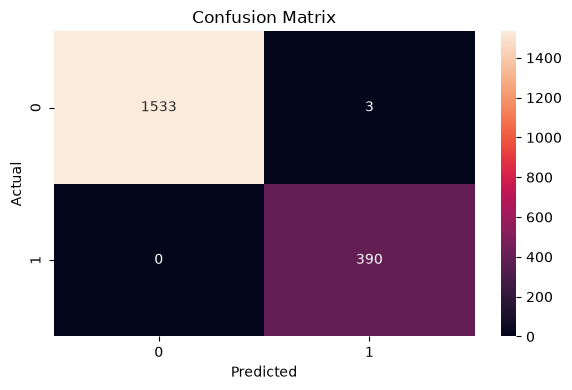

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1536
           1       0.99      1.00      1.00       390

    accuracy                           1.00      1926
   macro avg       1.00      1.00      1.00      1926
weighted avg       1.00      1.00      1.00      1926

0.001557632398753894


In [339]:
lr_pipeline.fit(x_train,y_train)
lr_prediction_test=lr_pipeline.predict(x_test)
lr_prediction_train=lr_pipeline.predict(x_train)
print('Traning Accuracy')
EvaluationMetrix(y_test=y_train,prediction=lr_prediction_train)
print('********'*10)
print('Testing Accuracy')
EvaluationMetrix(y_test=y_test,prediction=lr_prediction_test)
print(mean_absolute_error(y_test,lr_prediction_test))

Knn (Hyper parametre)

In [340]:
param_dist = {
    'Knn__n_neighbors':(1, 20),                    
    'Knn__weights': ['uniform', 'distance'],               
    'Knn__metric': ['euclidean', 'manhattan', 'minkowski'], 
    'Knn__p': [1, 2]                                      
}

In [341]:
knn_random=RandomizedSearchCV(estimator=knn_pipeline,param_distributions=param_dist,n_iter=10,cv=5,n_jobs=-1,random_state=24)

In [342]:
knn_random.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'Knn__metric': ['euclidean', 'manhattan', ...], 'Knn__n_neighbors': (1, ...), 'Knn__p': [1, 2], 'Knn__weights': ['uniform', 'distance']}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",24
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also f

Traning Accuracy


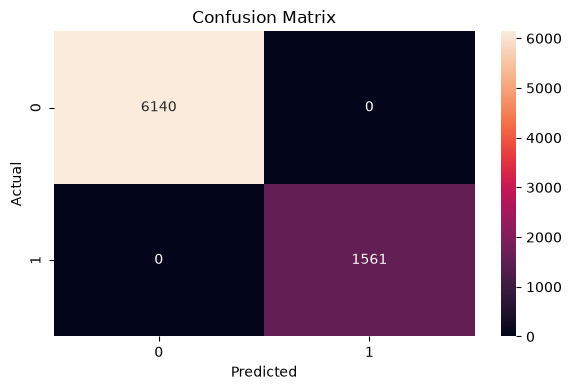

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6140
           1       1.00      1.00      1.00      1561

    accuracy                           1.00      7701
   macro avg       1.00      1.00      1.00      7701
weighted avg       1.00      1.00      1.00      7701

********************************************************************************
Testing Accuracy


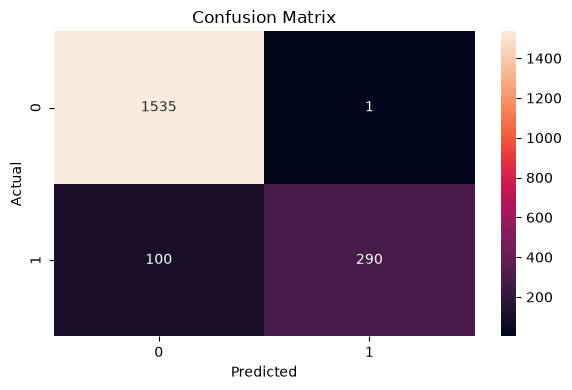

----------------------------------------
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1536
           1       1.00      0.74      0.85       390

    accuracy                           0.95      1926
   macro avg       0.97      0.87      0.91      1926
weighted avg       0.95      0.95      0.94      1926

0.052440290758047764


In [343]:
knn_random_test=knn_random.predict(x_test)
knn_random_train=knn_random.predict(x_train)
print('Traning Accuracy')
EvaluationMetrix(y_test=y_train,prediction=knn_random_train)
print('********'*10)
print('Testing Accuracy')
EvaluationMetrix(y_test=y_test,prediction=knn_random_test)
print(mean_absolute_error(y_test,knn_random_test))

knn (default)

Traning Accuracy


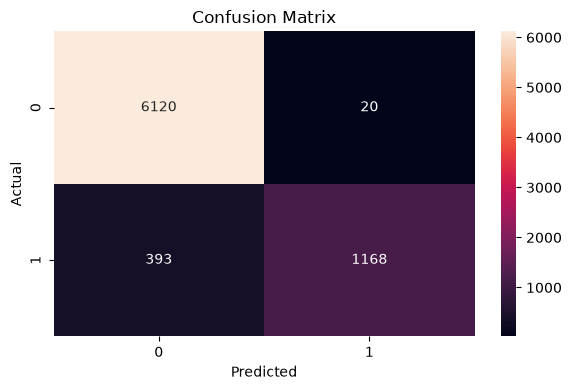

----------------------------------------
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      6140
           1       0.98      0.75      0.85      1561

    accuracy                           0.95      7701
   macro avg       0.96      0.87      0.91      7701
weighted avg       0.95      0.95      0.94      7701

********************************************************************************
Testing Accuracy


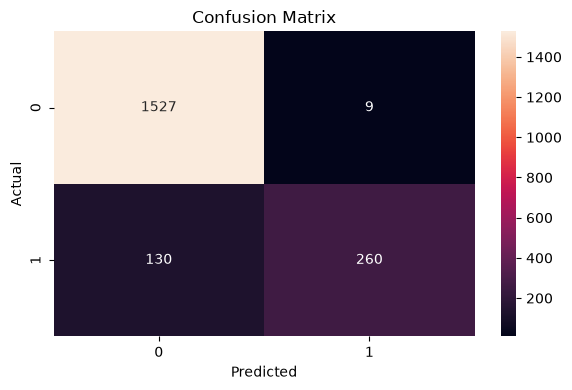

----------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      1536
           1       0.97      0.67      0.79       390

    accuracy                           0.93      1926
   macro avg       0.94      0.83      0.87      1926
weighted avg       0.93      0.93      0.92      1926

0.07217030114226376


In [344]:
knn_pipeline.fit(x_train,y_train)
knn_pipeline_train=knn_pipeline.predict(x_train)
knn_pipeline_test=knn_pipeline.predict(x_test)
print('Traning Accuracy')
EvaluationMetrix(y_test=y_train,prediction=knn_pipeline_train)
print('********'*10)
print('Testing Accuracy')
EvaluationMetrix(y_test=y_test,prediction=knn_pipeline_test)
print(mean_absolute_error(y_test,knn_pipeline_test))

BernouliNB (default)

Traning Accuracy


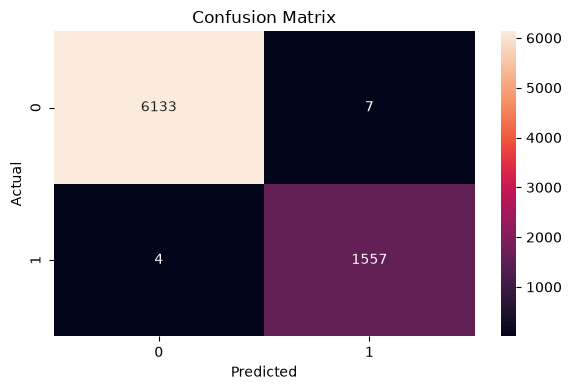

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6140
           1       1.00      1.00      1.00      1561

    accuracy                           1.00      7701
   macro avg       1.00      1.00      1.00      7701
weighted avg       1.00      1.00      1.00      7701

********************************************************************************
Testing Accuracy


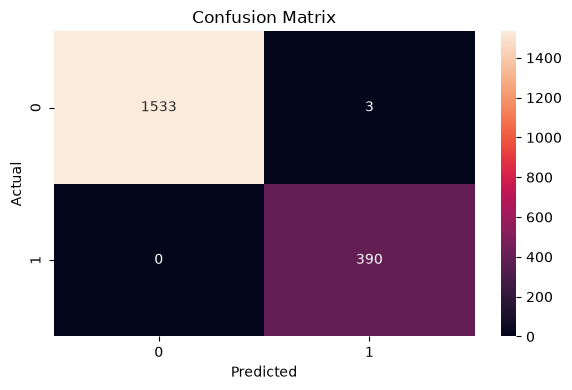

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1536
           1       0.99      1.00      1.00       390

    accuracy                           1.00      1926
   macro avg       1.00      1.00      1.00      1926
weighted avg       1.00      1.00      1.00      1926

0.001557632398753894


In [345]:
bernoulli_pipeline.fit(x_train,y_train)
bernoulli_pipeline_train=bernoulli_pipeline.predict(x_train)
bernoulli_pipeline_test=bernoulli_pipeline.predict(x_test)
print('Traning Accuracy')
EvaluationMetrix(y_test=y_train,prediction=bernoulli_pipeline_train)
print('********'*10)
print('Testing Accuracy')
EvaluationMetrix(y_test=y_test,prediction=bernoulli_pipeline_test)
print(mean_absolute_error(y_test,bernoulli_pipeline_test))

BernoulliNB (hyper pararmetre)

In [346]:
from scipy.stats import uniform,randint

In [347]:
param_dist_bernolli={
    'BernoulliNB__alpha': uniform(loc=0.0, scale=2.0), 
    'BernoulliNB__binarize': [None, 0.0, 0.2, 0.5, 0.8], 
    'BernoulliNB__fit_prior': [True, False] 
}

In [348]:
bernoulli_random=RandomizedSearchCV(param_distributions=param_dist_bernolli,n_iter=50,n_jobs=-1,random_state=24,scoring='accuracy',estimator=bernoulli_pipeline,cv=5)

In [349]:
bernoulli_random.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rnoulliNB())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'BernoulliNB__alpha': <scipy.stats....x753699879970>, 'BernoulliNB__binarize': [None, 0.0, ...], 'BernoulliNB__fit_prior': [True, False]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",24
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance

Traning Accuracy


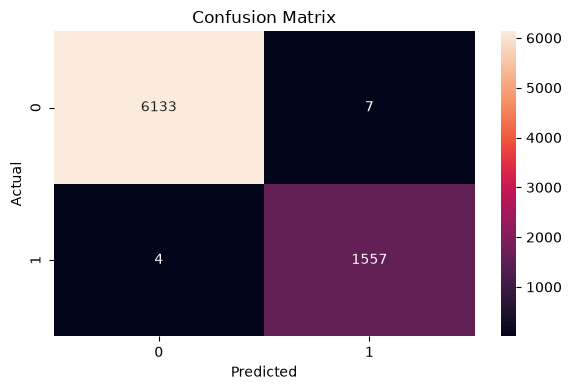

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6140
           1       1.00      1.00      1.00      1561

    accuracy                           1.00      7701
   macro avg       1.00      1.00      1.00      7701
weighted avg       1.00      1.00      1.00      7701

********************************************************************************
Testing Accuracy


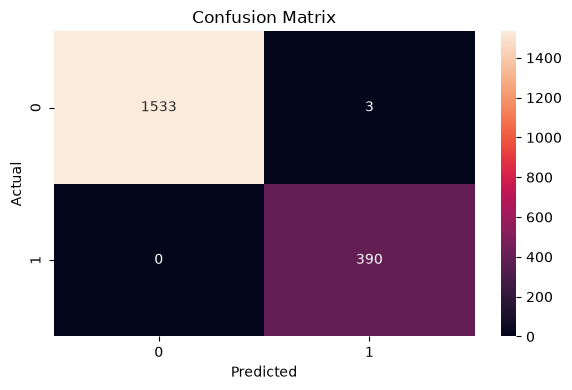

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1536
           1       0.99      1.00      1.00       390

    accuracy                           1.00      1926
   macro avg       1.00      1.00      1.00      1926
weighted avg       1.00      1.00      1.00      1926

0.001557632398753894


In [350]:
bernoulli_random_test=bernoulli_random.predict(x_test)
bernoulli_random_train=bernoulli_random.predict(x_train)
print('Traning Accuracy')
EvaluationMetrix(y_test=y_train,prediction=bernoulli_random_train)
print('********'*10)
print('Testing Accuracy')
EvaluationMetrix(y_test=y_test,prediction=bernoulli_random_test)
print(mean_absolute_error(y_test,bernoulli_random_test))

Decision Tree (default)

In [351]:
decision_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('DecisionTree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','CreditScore','Tenure',...,'HasCrCard','IsActiveMember','Complain']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('SkewFeature', ...), ('OtherNumFeature', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

Traning Accuracy


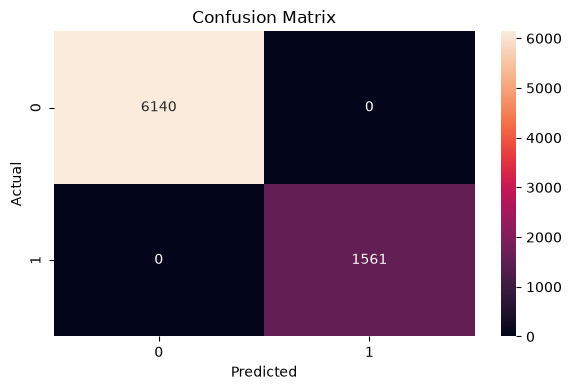

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6140
           1       1.00      1.00      1.00      1561

    accuracy                           1.00      7701
   macro avg       1.00      1.00      1.00      7701
weighted avg       1.00      1.00      1.00      7701

********************************************************************************
Testing Accuracy


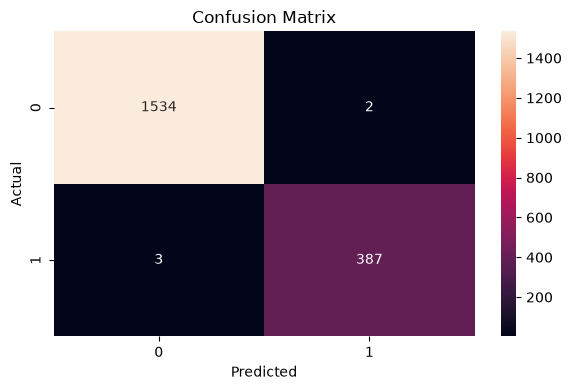

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1536
           1       0.99      0.99      0.99       390

    accuracy                           1.00      1926
   macro avg       1.00      1.00      1.00      1926
weighted avg       1.00      1.00      1.00      1926

0.002596053997923157


In [352]:
decision_pipeline_test=decision_pipeline.predict(x_test)
decision_pipeline_train=decision_pipeline.predict(x_train)
print('Traning Accuracy')
EvaluationMetrix(y_test=y_train,prediction=decision_pipeline_train)
print('********'*10)
print('Testing Accuracy')
EvaluationMetrix(y_test=y_test,prediction=decision_pipeline_test)
print(mean_absolute_error(y_test,decision_pipeline_test))

Decision Tree (hyper parametre)

In [353]:
param_dist_decision = {
    'DecisionTree__criterion': ['gini', 'entropy'],
    'DecisionTree__max_depth': [None] + list(range(5, 100, 5)),
    'DecisionTree__min_samples_split': randint(2, 15),
    'DecisionTree__min_samples_leaf': randint(1, 15),
    'DecisionTree__splitter': ['best', 'random']
}

In [354]:
decision_random=RandomizedSearchCV(estimator=decision_pipeline,param_distributions=param_dist_decision,n_iter=15,cv=5,random_state=24,scoring='accuracy',n_jobs=-1)

In [355]:
decision_random.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'DecisionTree__criterion': ['gini', 'entropy'], 'DecisionTree__max_depth': [None, 5, ...], 'DecisionTree__min_samples_leaf': <scipy.stats....x7536ab3bd790>, 'DecisionTree__min_samples_split': <scipy.stats....x7536ab3bfb30>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",24
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimato

Traning Accuracy


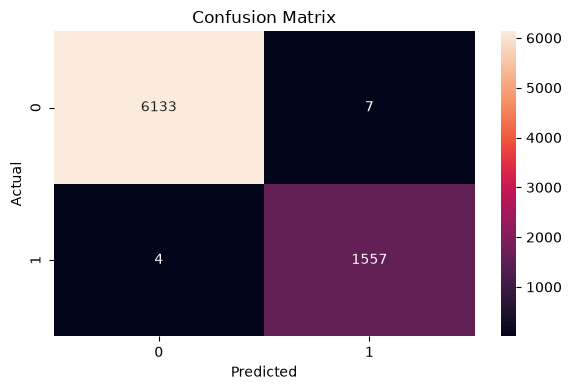

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6140
           1       1.00      1.00      1.00      1561

    accuracy                           1.00      7701
   macro avg       1.00      1.00      1.00      7701
weighted avg       1.00      1.00      1.00      7701

********************************************************************************
Testing Accuracy


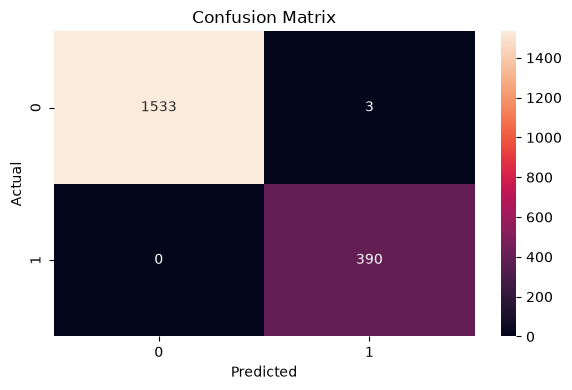

----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1536
           1       0.99      1.00      1.00       390

    accuracy                           1.00      1926
   macro avg       1.00      1.00      1.00      1926
weighted avg       1.00      1.00      1.00      1926

0.001557632398753894


In [356]:
decision_random_test=decision_random.predict(x_test)
decision_random_train=decision_random.predict(x_train)
print('Traning Accuracy')
EvaluationMetrix(y_test=y_train,prediction=decision_random_train)
print('********'*10)
print('Testing Accuracy')
EvaluationMetrix(y_test=y_test,prediction=decision_random_test)
print(mean_absolute_error(y_test,decision_random_test))

In [357]:
import joblib
joblib.dump(lr_pipeline,'BankChurn.pkl')

['BankChurn.pkl']

In [358]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'SatisfactionScore', 'CardType', 'PointEarned'],
      dtype='str')

In [359]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,9627.0,650.709982,96.124546,382.00,584.000,652.00,717.00,850.00
Gender,9627.0,0.546276,0.497880,0.00,0.000,1.00,1.00,1.00
Age,9627.0,37.782902,8.798411,18.00,32.000,37.00,43.00,62.00
Tenure,9627.0,5.016308,2.888474,0.00,3.000,5.00,7.00,10.00
Balance,9627.0,76537.860640,62400.900614,0.00,0.000,97268.10,127646.04,250898.09
NumOfProducts,9627.0,1.530903,0.580839,1.00,1.000,1.00,2.00,4.00
HasCrCard,9627.0,0.704996,0.456068,0.00,0.000,1.00,1.00,1.00
IsActiveMember,9627.0,0.503584,0.500013,0.00,0.000,1.00,1.00,1.00
EstimatedSalary,9627.0,100121.618686,57524.279118,11.58,51013.655,100187.43,149438.11,199992.48
Exited,9627.0,0.202659,0.402002,0.00,0.000,0.00,0.00,1.00


In [360]:
df.Geography.value_counts()

Geography
France     4826
Germany    2421
Spain      2380
Name: count, dtype: int64